In [5]:
import astropy.io.fits as pf
data = pf.open('DR16_absorber.fits')[1].data
print(data.dtype)
print(data.shape)

(numpy.record, [('CORRECTED_NABS_WITH_ALL_QSO', '>f8'), ('CORRECTED_NABS_WITH_QSO_SN_GR_1', '>f8'), ('CORRECTED_NABS_WITH_QSO_SN_GR_2', '>f8'), ('DEC_QSO', '>f8'), ('DELTA_V_MGII_2796', '>f8'), ('DELTA_V_MGII_2803', '>f8'), ('EIGENSPEC_INDEX', '>i8'), ('ERR_DELTA_V_MGII_2796', '>f8'), ('ERR_DELTA_V_MGII_2803', '>f8'), ('ERR_FWHM_VDISP_MGII_2796', '>f8'), ('ERR_FWHM_VDISP_MGII_2803', '>f8'), ('ERR_REST_EW_MGII_2796', '>f8'), ('ERR_REST_EW_MGII_2803', '>f8'), ('FIBER_ID', '>i8'), ('FWHM_VDISP_MGII_2796', '>f8'), ('FWHM_VDISP_MGII_2803', '>f8'), ('MJD', '>i8'), ('PARENT_QSO_ID', '>i8'), ('PLATE', '>i8'), ('RA_QSO', '>f8'), ('REST_EW_MGII_2796', '>f8'), ('REST_EW_MGII_2803', '>f8'), ('SNR_2796', '>f8'), ('SNR_2803', '>f8'), ('SNR_QSO_MEDIAN', '>f8'), ('Z_ABS', '>f8'), ('Z_ABS_ERR', '>f8'), ('Z_QSO', '>f8')])
(61823,)


In [9]:
import numpy as np
print(np.nanmedian(data['Z_ABS_ERR']))

4.19405332650058e-05


In [13]:
from astropy.coordinates import SkyCoord
from astropy import units as u

def crossmatch_catalogs(ra1, dec1, ra2, dec2, max_sep_arcsec=1.2):
    
    coords1 = SkyCoord(ra=ra1*u.degree, dec=dec1*u.degree)
    coords2 = SkyCoord(ra=ra2*u.degree, dec=dec2*u.degree)
    
    idx, sep2d, _ = coords1.match_to_catalog_sky(coords2)
    max_sep = max_sep_arcsec * u.arcsec

    matches = []
    no_matches = []

    for i, (match_idx, sep) in enumerate(zip(idx, sep2d)):
        if sep < max_sep:
            matches.append({
                'cat1_index': i,
                'cat2_index': match_idx,
                'separation_arcsec': sep.arcsec,
                'ra1': ra1[i],
                'dec1': dec1[i],
                'ra2': ra2[match_idx],
                'dec2': dec2[match_idx]
            })
        else:
            no_matches.append(i)

    return matches

In [11]:
desi = pf.open('MgII-Absorbers-EDR.fits')[1].data
print(desi.dtype)

(numpy.record, [('TARGETID', '>i8'), ('RA', '>f8'), ('DEC', '>f8'), ('SURVEY', 'S3'), ('ZWARN', '>i8'), ('TSNR2_QSO', '>f4'), ('TSNR2_LYA', '>f4'), ('TSNR2_LRG', '>f4'), ('Z_QSO', '>f8'), ('EW_2796', '>f8'), ('EW_2803', '>f8'), ('EW_2796_ERR_LOW', '>f8'), ('EW_2803_ERR_LOW', '>f8'), ('EW_2796_ERR_HIGH', '>f8'), ('EW_2803_ERR_HIGH', '>f8'), ('Z_MGII', '>f8'), ('AMP_2796', '>f8'), ('AMP_2803', '>f8'), ('STDDEV_2796', '>f8'), ('STDDEV_2803', '>f8'), ('Z_MGII_ERR_LOW', '>f8'), ('AMP_2796_ERR_LOW', '>f8'), ('AMP_2803_ERR_LOW', '>f8'), ('STDDEV_2796_ERR_LOW', '>f8'), ('STDDEV_2803_ERR_LOW', '>f8'), ('Z_MGII_ERR_HIGH', '>f8'), ('AMP_2796_ERR_HIGH', '>f8'), ('AMP_2803_ERR_HIGH', '>f8'), ('STDDEV_2796_ERR_HIGH', '>f8'), ('STDDEV_2803_ERR_HIGH', '>f8'), ('CONTINUUM_METHOD', 'S7'), ('LINE_SNR_MIN', '>f8'), ('LINE_SNR_MAX', '>f8')])


In [31]:
sdss_ra = data['RA_QSO']
sdss_dec = data['DEC_QSO']
desi_ra = desi['RA']
desi_dec = desi['DEC']
test = crossmatch_catalogs(sdss_ra,sdss_dec,desi_ra,desi_dec,max_sep_arcsec=0.5)
print(len(test),test)

3531 [{'cat1_index': 152, 'cat2_index': 2209, 'separation_arcsec': 0.05197627854830069, 'ra1': 178.44912719726562, 'dec1': -0.7737586498260498, 'ra2': 178.44914133501297, 'dec2': -0.7737615844830662}, {'cat1_index': 153, 'cat2_index': 11113, 'separation_arcsec': 0.07341989974477627, 'ra1': 178.16241455078125, 'dec1': -0.7683882117271423, 'ra2': 178.16243013994736, 'dec2': -0.7684013629185131}, {'cat1_index': 157, 'cat2_index': 11120, 'separation_arcsec': 0.05379631158311334, 'ra1': 179.03741455078125, 'dec1': -0.6863549947738647, 'ra2': 179.03740156946535, 'dec2': -0.6863475910305102}, {'cat1_index': 158, 'cat2_index': 2209, 'separation_arcsec': 0.004288502300846851, 'ra1': 178.4491424560547, 'dec1': -0.7737619876861572, 'ra2': 178.44914133501297, 'dec2': -0.7737615844830662}, {'cat1_index': 163, 'cat2_index': 2170, 'separation_arcsec': 0.018053907258872633, 'ra1': 178.42640686035156, 'dec1': 0.9281209707260132, 'ra2': 178.4264022543856, 'dec2': 0.9281229558231278}, {'cat1_index': 164,

In [33]:
sdss_index = [d['cat1_index'] for d in test]
# print(sdss_index)
desi_index = [d['cat2_index'] for d in test]
print(desi_index)

[2209, 11113, 11120, 2209, 2170, 8563, 11671, 4954, 2188, 11996, 11996, 8563, 11671, 11839, 12383, 4954, 2188, 11996, 11996, 11996, 10982, 4528, 4576, 11681, 11303, 2185, 4477, 11152, 4430, 4561, 4541, 11713, 11713, 4468, 4618, 4640, 5518, 8972, 8981, 11160, 12189, 11389, 11383, 5722, 5727, 11190, 11383, 11383, 5727, 11079, 11789, 11789, 5133, 11234, 11234, 11584, 5133, 11234, 11234, 11947, 11242, 11242, 12231, 5403, 11646, 4437, 4672, 12245, 12245, 8004, 8016, 5994, 6001, 6003, 5938, 12263, 12259, 12531, 12811, 2532, 12923, 12774, 12762, 12762, 12863, 12945, 12380, 12380, 5058, 12504, 12504, 12504, 5703, 12715, 5621, 5656, 5091, 5658, 5758, 17892, 12973, 13042, 13037, 2565, 12970, 12970, 12945, 13189, 8945, 8945, 13090, 9481, 449, 21386, 21386, 21386, 19922, 20033, 2382, 2360, 8002, 8001, 16592, 18887, 3651, 3491, 22829, 22900, 22688, 22787, 3666, 3621, 3621, 22944, 23097, 7266, 22961, 3871, 22962, 22630, 3842, 2789, 2787, 2789, 2787, 2787, 20291, 2789, 2789, 20299, 20299, 2787, 20291

In [49]:
sdss_z = data['Z_ABS'][sdss_index]
desi_z = desi['Z_MGII'][desi_index]
cata = np.where(np.abs(sdss_z-desi_z) > 1)[0]
out = np.where((np.abs(sdss_z-desi_z) < 1)&(np.abs(sdss_z-desi_z)/(1+desi_z)>0.15))[0]
len(cata)

194

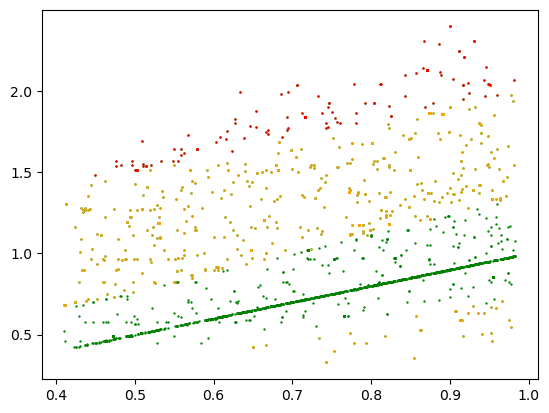

In [57]:
import matplotlib.pyplot as plt
plt.scatter(sdss_z,desi_z,s=0.5,color='green')
plt.scatter(sdss_z[out],desi_z[out],s=0.5,color='orange')
plt.scatter(sdss_z[cata],desi_z[cata],s=0.5,color='red')
# plt.ylim(0.4,1.0)

In [39]:
delta_z = (np.nanmedian(np.abs((sdss_z-desi_z))/(1+desi_z)))
print(delta_z)

8.640308622259698e-05
